In [180]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
data1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc', decode_timedelta=True) #***
parcel1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc', decode_timedelta=True) #***
res='1km';t_res='5min'
Np_str='1e6'

# # dx = 1km; Np = 50M; Nz = 95
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc', decode_timedelta=True) #***
# parcel1=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc', decode_timedelta=True) #***
# res='1km'; t_res='1min_95nz'; Np_str='50e6'

# # dx = 250m; Np = 50M
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_250m_1min_50M.nc', decode_timedelta=True) #***
# parcel1=xr.open_dataset(dir2+'cm1out_pdata_250m_1min_50M.nc', decode_timedelta=True) #***
# res='250m'; t_res='1min'; Np_str='50e6'

In [181]:
#LOADING IN H5 VARIABLES
PROCESSING=False
PROCESSING=True    
dir3=dir+'Project_Algorithms/Entrainment/OUTPUT/'

print('loading vars')
# if PROCESSING==False:
#     file_path=dir3+f'3D_entrainmentdetrainment_combined_profiles_{res}_{t_res}_{Np_str}.h5'
# elif PROCESSING==True:
#     file_path=dir3+f'3D_entrainmentdetrainment_combined_profiles_PREPROCESSING_{res}_{t_res}_{Np_str}.h5'
if PROCESSING==False:
    file_path=dir3+f'3D_entrainmentdetrainment_profiles_{res}_{t_res}_{Np_str}.h5'
elif PROCESSING==True:
    file_path=dir3+f'3D_entrainmentdetrainment_profiles_PREPROCESSING_{res}_{t_res}_{Np_str}.h5'

ED_ds1 = xr.open_dataset(file_path, phony_dims='sort',engine='h5netcdf')  # or engine='netcdf4'
ED_ds1 = ED_ds1.rename({
    'phony_dim_0': 'time',
    'phony_dim_1': 'zh',
    'phony_dim_2': 'yh',
    'phony_dim_3': 'xh'
})

if res=='1km':
    dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
elif res=='250m':
    dir2='/home/air673/koa_scratch/'
file_path = dir2 + 'Variable_Calculation/OUTPUT/' + f'Eulerian_Binary_Array_{res}_{t_res}.h5'
A_ds1 = xr.open_dataset(file_path, phony_dims='sort',engine='h5netcdf')  # or engine='netcdf4'
A_ds1 = A_ds1.rename({
    'phony_dim_0': 'time',
    'phony_dim_1': 'zh',
    'phony_dim_2': 'yh',
    'phony_dim_3': 'xh'
})
print('done')

loading vars
done


In [182]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [183]:
#DOMAIN SUBSETTING
############################################################

#FINDING NEW LEFT T-BOUNDARY
dt=data1['time'][1].item()/1e9 #seconds per timestep
dhours=(dt/60**2) #hours per timestep
start_hour=4 #10:00 am
t_start=int(start_hour/dhours)
#FINDING NEW RIGHT T-BOUNDARY
end_hour=11 #5pm
t_end=int(end_hour/dhours)
#PRINTING
print(f't in {t_start}:{t_end}')


#FINDING NEW TOP Z-BOUNDARY
dzh=data1['zh']
zh_bottom=0; zh_top=np.where(dzh>=19)[0][0]
dzf=data1['zf']
zf_bottom=0; zf_top=np.where(dzf>=20)[0][0]
#PRINTING
print(f'zh_top at {zh_bottom}:{zh_top}')

#FINDING THE NEW LEFT X-BOUNDARY
ocean_percent=2/8
left_to_coast=data1['xh'][0]+(data1['xh'][-1]-data1['xh'][0])*ocean_percent
where_coast_xh=np.where(data1['xh']>=left_to_coast)[0][0]#-25
where_coast_xf=np.where(data1['xf']>=left_to_coast)[0][0]#-25

#FINDING THE NEW RIGHT X-BOUNDARY
right_fraction=80/100
# Normalize to start from zero
xf = data1['xf'] - data1['xf'][0]
xh = data1['xh'] - data1['xh'][0]

# Total physical length
xf_max = xf[-1]
xh_max = xh[-1]

# Find index where physical location exceeds 80% of domain
end_xf = np.where(xf > right_fraction * xf_max)[0][0]
end_xh = np.where(xh > right_fraction * xh_max)[0][0]

# Example: printing region from coast to 80% mark
print(f'x in {where_coast_xh}:{end_xh} FOR LAND')

# SUBSETTING CODE
data1=data1.isel(time=slice(t_start,None),zh=slice(zh_bottom,zh_top),xh=slice(where_coast_xh,end_xh+1))
ED_ds1=ED_ds1.isel(time=slice(t_start,None),zh=slice(zh_bottom,zh_top),xh=slice(where_coast_xh,end_xh+1))
A_ds1=A_ds1.isel(time=slice(t_start,None),zh=slice(zh_bottom,zh_top),xh=slice(where_coast_xh,end_xh+1))

t in 48:132
zh_top at 0:33
x in 128:409 FOR LAND


In [200]:
one=ED_ds1['profile_array_g_to_c_E'].isel(time=70).data
two=ED_ds1['profile_array_g_to_c_D'].isel(time=70).data

w=data1['winterp'].isel(time=70).data
qc=data1['qc'].isel(time=70).data
qi=data1['qi'].isel(time=70).data
qcqi=qc+qi

In [201]:
#TESTING REMOVING ZEROS
# one[one==0]=np.nan; two[two==0]=np.nan

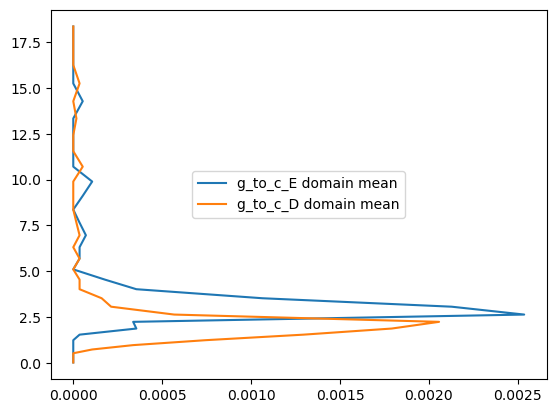

In [202]:
#CALCULATING MEAN
Profile_one=np.nanmean(one,axis=(1,2))
Profile_two=np.nanmean(two,axis=(1,2))

#PLOTTING
plt.plot(Profile_one,data1['zh'],label='g_to_c_E domain mean')
plt.plot(Profile_two,data1['zh'],label='g_to_c_D domain mean')
plt.legend(loc='center')

/tmp/ipykernel_51675/3978784335.py:11: RuntimeWarning: Mean of empty slice
  Profile_one_c = np.nanmean(np.where(mask_c, one, np.nan), axis=(1, 2))
/tmp/ipykernel_51675/3978784335.py:13: RuntimeWarning: Mean of empty slice
  Profile_two_c = np.nanmean(np.where(mask_c, two, np.nan), axis=(1, 2))


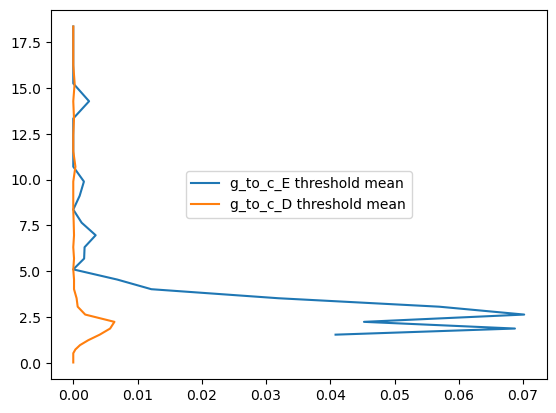

In [203]:
#CALCULATING THRESHOLD MEAN

w_thresh1=0.1
w_thresh2=0.5
qcqi_thresh=1e-6

mask_g = (w >= w_thresh1) & (qcqi < qcqi_thresh)
mask_c = (w >= w_thresh2) & (qcqi >= qcqi_thresh)

Profile_one_g = np.nanmean(np.where(mask_g, one, np.nan), axis=(1, 2))
Profile_one_c = np.nanmean(np.where(mask_c, one, np.nan), axis=(1, 2))
Profile_two_g = np.nanmean(np.where(mask_g, two, np.nan), axis=(1, 2))
Profile_two_c = np.nanmean(np.where(mask_c, two, np.nan), axis=(1, 2))

#PLOTTING
plot_one=Profile_one_c
plot_two=Profile_two_g

plt.plot(plot_one,data1['zh'],label='g_to_c_E threshold mean')
plt.plot(plot_two,data1['zh'],label='g_to_c_D threshold mean')
plt.legend(loc='center')

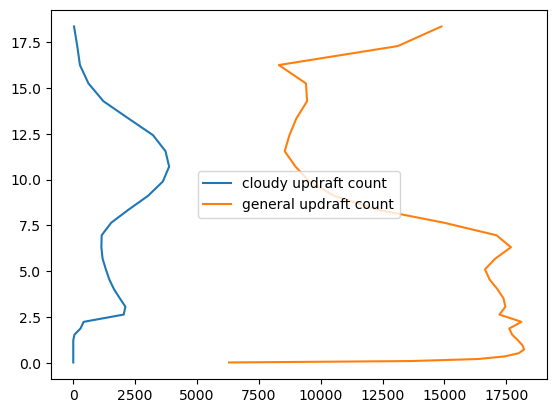

In [204]:
#COUNT OF GENERAL AND CLOUDY UPDRAFT GRIDBOXES

mask_c_3d = np.broadcast_to(mask_c, one.shape)
count_per_level1 = np.sum(mask_c_3d, axis=(1, 2))

mask_g_3d = np.broadcast_to(mask_g, one.shape)
count_per_level2 = np.sum(mask_g_3d, axis=(1, 2))

plt.plot(count_per_level1,data1['zh'],label='cloudy updraft count')
plt.plot(count_per_level2,data1['zh'],label='general updraft count')
plt.legend(loc='center')

In [205]:
#COUNT OF 0s,1s,2s,and 3s of data for GENERAL AND CLOUDY UPDRAFT GRIDBOXES

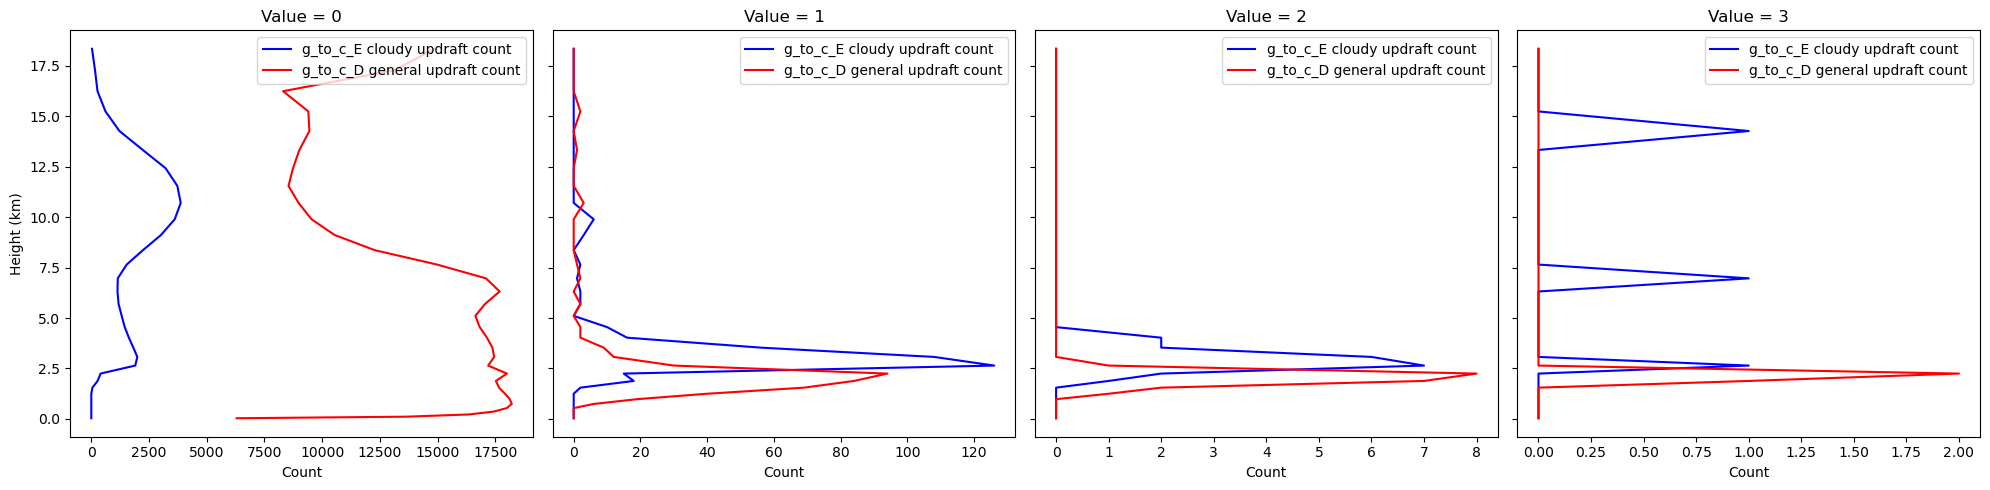

In [206]:
#CALCULATING THRESHOLD MEAN
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for i, value in enumerate([0, 1, 2, 3]):
    # Apply masks for general and cloudy updrafts
    mask_g2 = (w >= w_thresh1) & (qcqi < qcqi_thresh) & (two == value)
    mask_c2 = (w >= w_thresh2) & (qcqi >= qcqi_thresh) & (one == value)

    # Broadcast masks and count per vertical level
    mask_c_3d = np.broadcast_to(mask_c2, one.shape)
    count_per_level1 = np.sum(mask_c_3d, axis=(1, 2))

    mask_g_3d = np.broadcast_to(mask_g2, one.shape)
    count_per_level2 = np.sum(mask_g_3d, axis=(1, 2))

    # Plotting in subplot
    ax = axs[i]
    ax.plot(count_per_level1, data1['zh'], label='g_to_c_E cloudy updraft count', color='blue')
    ax.plot(count_per_level2, data1['zh'], label='g_to_c_D general updraft count', color='red')
    ax.set_title(f'Value = {value}')
    ax.set_xlabel('Count')
    if i == 0:
        ax.set_ylabel('Height (km)')
    ax.legend()
plt.tight_layout()